# EGFR "Virtual Biopsy" — v3.2: hand-crafted radiomics alongside the deep image branch

**Same cohort (N=139, 33 positives) and same evaluation (repeated 5x5 stratified CV) as v3.1**, so every
number is directly comparable. The only thing added is a **radiomics branch**: ~30 hand-crafted features
(first-order intensity, rough shape, GLCM texture) computed from each tumour cube. These encode the domain
priors a CNN must learn from scratch, which usually helps on small CT cohorts.

**This is built as an ablation so the data decides "alongside vs instead":**
- `radiomics-only (logreg)` and `clinical+radiomics (logreg)` — instant, no deep training.
- `image+clinical+radiomics (FULL)` — the deep "alongside" model.
- Compare `FULL` vs `clinical+radiomics (logreg)`: if equal, the deep image branch is redundant and you
  should drop it (the "instead" outcome — simpler, more publishable). If FULL is clearly higher, keep both.

No leakage: radiomics features are standardised with **train-fold statistics only**, inside each CV fold.


## 1. Install (run once)

In [1]:
import sys
# !{sys.executable} -m pip install -q "pydicom<3" pydicom-seg SimpleITK scipy scikit-learn scikit-image matplotlib tqdm torchvision
print("done")
# !pip3 install torch torchvision --index-url https://download.pytorch.org/whl/cu126

done


## 2. Imports

In [2]:
import os, glob, shutil, random, warnings, math, numpy as np, pandas as pd
import xml.etree.ElementTree as ET
from pathlib import Path
import pydicom, pydicom_seg, SimpleITK as sitk
from scipy import ndimage
from scipy.stats import skew, kurtosis
from skimage.feature import graycomatrix, graycoprops
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as tvm
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, roc_curve
try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **k): return x
warnings.filterwarnings("ignore")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Torch", torch.__version__, "| Device:", DEVICE)

d:\git\PhDProjects\LungCancerGrading\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Torch 2.12.1+cu126 | Device: cuda


## 3. CONFIG

In [3]:
DATA_ROOT    = Path("data/nsclc_radiogenomics")
CLINICAL_CSV = Path("data/NSCLCR01Radiogenomic_DATA_LABELS_2018-05-22_1500-shifted.csv")
AIM_DIR      = Path("data/AIM_files_updated-11-10-2020/AIM_files_updated-11-10-2020")
CACHE_BASE   = Path("egfr_cache")
OUTPUT_DIR   = Path("egfr_out"); OUTPUT_DIR.mkdir(exist_ok=True)

TARGET_COL, POS_LABEL, NEG_LABEL = "EGFR mutation status", "Mutant", "Wildtype"

TARGET_SHAPE   = (32, 64, 64); CROP_PAD_VOX = 16
HU_MIN, HU_MAX = -1000, 400
REQUIRE_SEG    = False
USE_AIM_COORD_FALLBACK = True
ALLOW_CENTER_CROP_FALLBACK = False
AIM_DEPTH_SLICES = TARGET_SHAPE[0]
FORCE_REBUILD  = False

INCLUDE_HISTOLOGY = False
INCLUDE_ETHNICITY = True

IMAGE_BACKBONE = "2.5d"            # keep 2.5d (best/most stable image branch)
PRETRAINED     = True
IMG_FEAT_DIM   = 64; TAB_HIDDEN = 64; FUSION_HIDDEN = 64; DROPOUT = 0.4
FREEZE_SLICE_BACKBONE=True; VIT_D_MODEL=192; VIT_HEADS=3; VIT_LAYERS=2; VIT_FF=384; SLICE_RES=224

N_FOLDS = 5; N_REPEATS = 5; EPOCHS = 60; LR = 1e-4; WEIGHT_DECAY = 1e-4
BATCH_SIZE = 8; USE_AUGMENTATION = True; USE_CLASS_WEIGHTS = True; SEED = 0
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

PRE_TAG = f"seg{int(REQUIRE_SEG)}_aim{int(USE_AIM_COORD_FALLBACK)}_{TARGET_SHAPE[0]}x{TARGET_SHAPE[1]}x{TARGET_SHAPE[2]}_pad{CROP_PAD_VOX}"
CACHE_DIR = CACHE_BASE / PRE_TAG
if FORCE_REBUILD and CACHE_DIR.exists(): shutil.rmtree(CACHE_DIR)
CACHE_DIR.mkdir(parents=True, exist_ok=True)
print("cache:", CACHE_DIR)

cache: egfr_cache\seg0_aim1_32x64x64_pad16


## 4. Clinical labels + tabular features

In [4]:
clin = pd.read_csv(CLINICAL_CSV)
clin["Case ID"] = clin["Case ID"].astype(str).str.strip()
clin["label"] = clin[TARGET_COL].map({POS_LABEL: 1, NEG_LABEL: 0})
clin = clin.dropna(subset=["label"]).copy(); clin["label"] = clin["label"].astype(int)
print("Usable EGFR labels:", len(clin)); print(clin["label"].value_counts().rename({0:NEG_LABEL,1:POS_LABEL}))

def build_tabular(df):
    f = pd.DataFrame(index=df.index)
    age = pd.to_numeric(df["Age at Histological Diagnosis"], errors="coerce")
    f["age"] = age.fillna(age.median())/100.0
    f["male"] = (df["Gender"].astype(str).str.strip().str.lower()=="male").astype(float)
    sm = df["Smoking status"].astype(str).str.strip()
    for v in ["Nonsmoker","Former","Current"]: f[f"smk_{v}"] = (sm==v).astype(float)
    for c in [c for c in df.columns if c.startswith("Tumor Location")]:
        key = c.split("choice=")[-1].rstrip(")").strip().replace(" ","_")
        f[f"loc_{key}"] = (df[c].astype(str).str.strip().str.lower()=="checked").astype(float)
    f = pd.concat([f, pd.get_dummies(df["%GG"].astype(str).str.strip(), prefix="gg").astype(float)], axis=1)
    if INCLUDE_ETHNICITY and "Ethnicity" in df.columns:
        f = pd.concat([f, pd.get_dummies(df["Ethnicity"].astype(str).str.strip(), prefix="eth").astype(float)], axis=1)
    if INCLUDE_HISTOLOGY:
        f = pd.concat([f, pd.get_dummies(df["Histology "].astype(str).str.strip(), prefix="hist").astype(float)], axis=1)
    return f
print("Tabular features:", build_tabular(clin).shape[1])

Usable EGFR labels: 172
label
Wildtype    129
Mutant       43
Name: count, dtype: int64
Tabular features: 25


## 5. Index DICOM + match AIM files

In [5]:
ALL_AIM = glob.glob(os.path.join(str(AIM_DIR), "*.xml")) if AIM_DIR.exists() else []
def aim_file_for(cid):
    mf = [f for f in ALL_AIM if cid in os.path.basename(f)]
    return mf[0] if mf else None

def scan_patient(pdir):
    info = {"ct_dir": None, "ct_n": 0, "seg_file": None, "seg_modality": None}
    for root, _, files in os.walk(pdir):
        dcms = [f for f in files if f.lower().endswith(".dcm")]
        if not dcms: continue
        try: ds = pydicom.dcmread(os.path.join(root, dcms[0]), stop_before_pixels=True, force=True)
        except Exception: continue
        mod = str(getattr(ds, "Modality", "")).upper()
        if mod == "CT":
            if len(dcms) > info["ct_n"]: info["ct_dir"], info["ct_n"] = root, len(dcms)
        elif mod in ("SEG","RTSTRUCT"):
            info["seg_file"], info["seg_modality"] = os.path.join(root, dcms[0]), mod
    return info

records = []
for cid in tqdm(clin["Case ID"].tolist(), desc="indexing"):
    pdir = DATA_ROOT/cid
    info = scan_patient(pdir) if pdir.exists() else {"ct_dir":None,"ct_n":0,"seg_file":None,"seg_modality":None}
    info["Case ID"] = cid; info["aim_file"] = aim_file_for(cid); records.append(info)
cohort = clin.merge(pd.DataFrame(records), on="Case ID", how="left")
print("CT:", cohort["ct_dir"].notna().sum(), "| SEG:", (cohort["seg_modality"]=="SEG").sum(),
      "| AIM:", cohort["aim_file"].notna().sum())

indexing: 100%|██████████| 172/172 [00:22<00:00,  7.70it/s]

CT: 172 | SEG: 117 | AIM: 158


## 6. AIM markup parser + coordinate cropper

In [6]:
def _local(t): return t.rsplit('}',1)[-1]
def parse_aim_markup(xml_path):
    out=[]
    try: root=ET.parse(xml_path).getroot()
    except Exception: return out
    for me in root.iter():
        if _local(me.tag)!="MarkupEntity": continue
        sop=None;frame=None;pts=[]
        for el in me.iter():
            lt=_local(el.tag)
            if lt=="imageReferenceUid": sop=el.get("root")
            elif lt=="referencedFrameNumber": frame=el.get("value")
            elif lt=="TwoDimensionSpatialCoordinate":
                x=y=None
                for c in el:
                    if _local(c.tag)=="x": x=float(c.get("value"))
                    if _local(c.tag)=="y": y=float(c.get("value"))
                if x is not None and y is not None: pts.append((x,y))
        if pts: out.append({"sop":sop,"frame":frame,"xy":pts})
    return out

def sop_to_zindex(ct_dir):
    files=sitk.ImageSeriesReader().GetGDCMSeriesFileNames(str(ct_dir)); m={}
    for i,fp in enumerate(files):
        try:
            ds=pydicom.dcmread(fp,stop_before_pixels=True,force=True); m[str(getattr(ds,'SOPInstanceUID',''))]=i
        except Exception: pass
    return m

def _finish_cube(crop):
    if crop.size==0 or min(crop.shape)<2: return None
    crop=ndimage.zoom(crop.astype(np.float32),[t/max(1,s) for t,s in zip(TARGET_SHAPE,crop.shape)],order=1)
    crop=np.clip(crop,HU_MIN,HU_MAX)
    return ((crop-HU_MIN)/(HU_MAX-HU_MIN)).astype(np.float32)

def crop_from_aim(ct_arr, sop_map, markups):
    Z,Y,X=ct_arr.shape
    for mk in markups:
        if mk["sop"] not in sop_map: continue
        z=sop_map[mk["sop"]]; pts=mk["xy"]; cx,cy=pts[0]
        r=math.hypot(pts[1][0]-cx,pts[1][1]-cy) if len(pts)>=2 else 25.0
        r=max(r,10.0); half=int(round(r))+CROP_PAD_VOX; dz=AIM_DEPTH_SLICES//2
        y0,y1=max(0,int(cy)-half),min(Y,int(cy)+half); x0,x1=max(0,int(cx)-half),min(X,int(cx)+half)
        z0,z1=max(0,z-dz),min(Z,z+dz)
        cube=_finish_cube(ct_arr[z0:z1,y0:y1,x0:x1])
        if cube is not None: return cube,"ok"
    return None,"no_resolvable_markup"

## 7. Preprocess -> tumour cubes (SEG first, AIM fallback) — reuses v3.1 cache

In [7]:
def load_ct(ct_dir):
    r=sitk.ImageSeriesReader(); r.SetFileNames(r.GetGDCMSeriesFileNames(str(ct_dir))); return r.Execute()
def seg_mask_on_ct(seg_file, ct_img):
    result=pydicom_seg.SegmentReader().read(pydicom.dcmread(seg_file)); mask=None
    for num in result.available_segments:
        res=sitk.Resample(result.segment_image(num),ct_img,sitk.Transform(),sitk.sitkNearestNeighbor,0,sitk.sitkUInt8)
        a=sitk.GetArrayFromImage(res).astype(bool); mask=a if mask is None else (mask|a)
    return mask
def crop_to_cube(ct_arr, mask):
    if mask is not None and mask.any():
        zz,yy,xx=np.where(mask); p=CROP_PAD_VOX
        z0,z1=max(0,zz.min()-p),min(ct_arr.shape[0],zz.max()+p+1)
        y0,y1=max(0,yy.min()-p),min(ct_arr.shape[1],yy.max()+p+1)
        x0,x1=max(0,xx.min()-p),min(ct_arr.shape[2],xx.max()+p+1)
    else:
        Z,Y,X=ct_arr.shape; z0,z1=int(Z*.25),int(Z*.75);y0,y1=int(Y*.2),int(Y*.8);x0,x1=int(X*.2),int(X*.8)
    return _finish_cube(ct_arr[z0:z1,y0:y1,x0:x1])

status=[]
for _,row in tqdm(cohort.iterrows(), total=len(cohort), desc="preprocess"):
    cid=row["Case ID"]; out=CACHE_DIR/f"{cid}.npy"
    if out.exists(): status.append((cid,"cached")); continue
    if pd.isna(row["ct_dir"]): status.append((cid,"no_ct")); continue
    try:
        ct=load_ct(row["ct_dir"]); ct_arr=sitk.GetArrayFromImage(ct); mask=None
        if row["seg_modality"]=="SEG":
            try: mask=seg_mask_on_ct(row["seg_file"],ct)
            except Exception: mask=None
        if mask is not None and mask.any():
            cube=crop_to_cube(ct_arr,mask)
            if cube is not None: np.save(out,cube); status.append((cid,"ok_seg")); continue
        if USE_AIM_COORD_FALLBACK and isinstance(row["aim_file"],str):
            markups=parse_aim_markup(row["aim_file"])
            if markups:
                cube,_=crop_from_aim(ct_arr,sop_to_zindex(row["ct_dir"]),markups)
                if cube is not None: np.save(out,cube); status.append((cid,"ok_aim")); continue
                status.append((cid,"aim_unresolved")); continue
            status.append((cid,"aim_no_markup")); continue
        if ALLOW_CENTER_CROP_FALLBACK and not REQUIRE_SEG:
            cube=crop_to_cube(ct_arr,None)
            if cube is not None: np.save(out,cube); status.append((cid,"ok_centercrop")); continue
        status.append((cid,"no_seg_skipped"))
    except Exception as e: status.append((cid,f"error:{type(e).__name__}"))

st=pd.DataFrame(status,columns=["Case ID","status"]); print(st["status"].value_counts())
cohort=cohort.merge(st,on="Case ID",how="left")
cohort=cohort[cohort["status"].isin(["ok_seg","ok_aim","ok_centercrop","cached"])].reset_index(drop=True)
print("\nFinal cohort:",len(cohort)); print(cohort["label"].value_counts().rename({0:NEG_LABEL,1:POS_LABEL}))

preprocess: 100%|██████████| 172/172 [01:43<00:00,  1.66it/s]

status
cached            139
aim_unresolved     20
no_seg_skipped     13
Name: count, dtype: int64

Final cohort: 139
label
Wildtype    106
Mutant       33
Name: count, dtype: int64


## 8. Radiomics features (first-order + shape + GLCM texture)

Computed on each cached cube. A rough tumour ROI is found by thresholding the cube (tumour is denser than
lung) and taking the central connected component; features are computed inside it. ~30 features, the same
for SEG and AIM crops. Cached to CSV so it only runs once.

In [8]:
def tumor_roi(cube, thr=0.5):
    m=cube>thr; D,H,W=cube.shape
    if not m.any():
        m=np.zeros_like(cube,bool); m[D//4:3*D//4,H//4:3*H//4,W//4:3*W//4]=True; return m
    lbl,n=ndimage.label(m); cl=lbl[D//2,H//2,W//2]
    if cl>0: return lbl==cl
    sizes=ndimage.sum(np.ones_like(lbl),lbl,index=range(1,n+1))
    return lbl==(1+int(np.argmax(sizes)))

def radiomics_features(cube):
    f={}; roi=tumor_roi(cube); vals=cube[roi]
    if vals.size<8: vals=cube.ravel()
    f["fo_mean"]=vals.mean(); f["fo_std"]=vals.std(); f["fo_median"]=np.median(vals)
    f["fo_p10"]=np.percentile(vals,10); f["fo_p90"]=np.percentile(vals,90)
    f["fo_iqr"]=np.percentile(vals,75)-np.percentile(vals,25)
    f["fo_min"]=vals.min(); f["fo_max"]=vals.max(); f["fo_range"]=vals.max()-vals.min()
    f["fo_mad"]=np.mean(np.abs(vals-vals.mean())); f["fo_skew"]=skew(vals); f["fo_kurt"]=kurtosis(vals)
    f["fo_energy"]=np.mean(vals**2)
    cnt,_=np.histogram(vals,bins=32,range=(0,1)); p=cnt/max(1,cnt.sum()); pp=p[p>0]
    f["fo_entropy"]=-(pp*np.log2(pp)).sum(); f["fo_uniformity"]=(p**2).sum()
    vol=float(roi.sum()); f["sh_volume"]=vol; coords=np.argwhere(roi)
    if len(coords)>0:
        bb=coords.max(0)-coords.min(0)+1
        f["sh_extent"]=vol/float(np.prod(bb)); f["sh_elongation"]=float(bb.min()/max(1,bb.max()))
    else: f["sh_extent"]=0.0; f["sh_elongation"]=0.0
    er=ndimage.binary_erosion(roi); surf=float((roi&~er).sum())
    f["sh_surface"]=surf; f["sh_sa_vol"]=surf/max(1.0,vol)
    f["sh_sphericity"]=float((4*np.pi*((3*vol/(4*np.pi))**(2/3)))/max(1.0,surf)) if vol>0 else 0.0
    areas=roi.sum((1,2)); z=int(np.argmax(areas)) if areas.max()>0 else cube.shape[0]//2
    sl=cube[z]
    if roi[z].any():
        ys,xs=np.where(roi[z]); sl=sl[ys.min():ys.max()+1, xs.min():xs.max()+1]
    levels=16; q=np.clip((sl*(levels-1)).round(),0,levels-1).astype(np.uint8)
    props=["contrast","dissimilarity","homogeneity","energy","correlation","ASM"]
    if min(q.shape)>=3:
        glcm=graycomatrix(q,distances=[1],angles=[0,np.pi/4,np.pi/2,3*np.pi/4],levels=levels,symmetric=True,normed=True)
        for pr in props: f[f"tex_{pr}"]=float(np.nan_to_num(graycoprops(glcm,pr).mean()))
    else:
        for pr in props: f[f"tex_{pr}"]=0.0
    return f

RAD_CACHE=OUTPUT_DIR/f"radiomics_{PRE_TAG}.csv"
if RAD_CACHE.exists():
    rad_df=pd.read_csv(RAD_CACHE).set_index("Case ID")
else:
    rows={}
    for cid in tqdm(cohort["Case ID"], desc="radiomics"):
        rows[cid]=radiomics_features(np.load(CACHE_DIR/f"{cid}.npy"))
    rad_df=pd.DataFrame.from_dict(rows,orient="index"); rad_df.index.name="Case ID"
    rad_df.reset_index().to_csv(RAD_CACHE,index=False)
rad_df=rad_df.reindex(cohort["Case ID"]).fillna(0.0)
rad_mat_raw=np.nan_to_num(rad_df.values.astype(np.float32))
N_RAD=rad_mat_raw.shape[1]
RAD_MAT=np.nan_to_num(StandardScaler().fit_transform(rad_mat_raw)).astype(np.float32)
print("Radiomics features:",N_RAD); print(list(rad_df.columns))

radiomics: 100%|██████████| 139/139 [00:01<00:00, 91.62it/s]

Radiomics features: 27
['fo_mean', 'fo_std', 'fo_median', 'fo_p10', 'fo_p90', 'fo_iqr', 'fo_min', 'fo_max', 'fo_range', 'fo_mad', 'fo_skew', 'fo_kurt', 'fo_energy', 'fo_entropy', 'fo_uniformity', 'sh_volume', 'sh_extent', 'sh_elongation', 'sh_surface', 'sh_sa_vol', 'sh_sphericity', 'tex_contrast', 'tex_dissimilarity', 'tex_homogeneity', 'tex_energy', 'tex_correlation', 'tex_ASM']


## 9. SANITY — eyeball a few crops

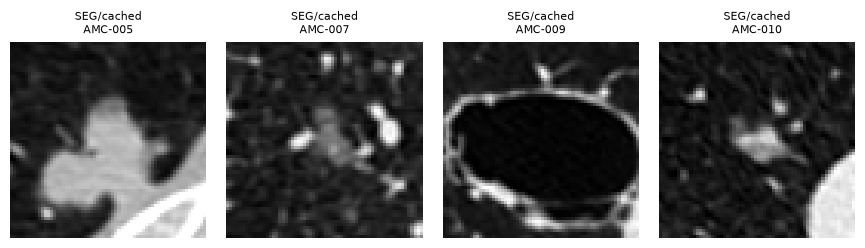

In [9]:
import matplotlib.pyplot as plt
aim_ids=cohort.loc[cohort["status"]=="ok_aim","Case ID"].tolist()[:5]
seg_ids=cohort.loc[cohort["status"].isin(["ok_seg","cached"]),"Case ID"].tolist()[:4]
show=[("AIM",c) for c in aim_ids]+[("SEG/cached",c) for c in seg_ids]
if show:
    n=len(show); fig,ax=plt.subplots(1,n,figsize=(2.2*n,2.4))
    if n==1: ax=[ax]
    for a,(src,cid) in zip(ax,show):
        cube=np.load(CACHE_DIR/f"{cid}.npy"); a.imshow(cube[cube.shape[0]//2],cmap="gray")
        a.set_title(f"{src}\n{cid}",fontsize=8); a.axis("off")
    plt.tight_layout(); plt.show()

## 10. Tabular matrix + Dataset (now returns image, clinical, radiomics, label)

In [10]:
tab_mat=build_tabular(cohort).values.astype(np.float32)
N_TAB=tab_mat.shape[1]; labels=cohort["label"].values.astype(np.float32)
print("Tabular dim:",N_TAB,"| Radiomics dim:",N_RAD,"| N:",len(cohort),"| positives:",int(labels.sum()))

def augment_cube(cube):
    if random.random()<0.5: cube=torch.flip(cube,dims=[2])
    if random.random()<0.5: cube=torch.flip(cube,dims=[3])
    cube=cube*random.uniform(0.9,1.1)+random.uniform(-0.05,0.05)
    return cube.clamp(0,1)

class EGFRDataset(Dataset):
    def __init__(self, indices, train=False):
        self.indices=list(indices); self.train=train
    def __len__(self): return len(self.indices)
    def __getitem__(self,k):
        i=self.indices[k]
        cube=np.load(CACHE_DIR/f"{cohort.iloc[i]['Case ID']}.npy")
        img=torch.from_numpy(cube).float().unsqueeze(0)
        if self.train and USE_AUGMENTATION: img=augment_cube(img)
        tab=torch.from_numpy(tab_mat[i]).float()
        rad=torch.from_numpy(RAD_MAT[i]).float()
        y=torch.tensor([labels[i]],dtype=torch.float32)
        return img,tab,rad,y

Tabular dim: 25 | Radiomics dim: 27 | N: 139 | positives: 33


## 11. Model — image (2.5D) + clinical MLP + radiomics MLP -> fusion

In [11]:
class Image25DEncoder(nn.Module):
    def __init__(self,out_dim=IMG_FEAT_DIM,pretrained=PRETRAINED,p=DROPOUT):
        super().__init__()
        net=tvm.resnet18(weights=tvm.ResNet18_Weights.DEFAULT if pretrained else None)
        self.features=nn.Sequential(*list(net.children())[:-1])
        self.proj=nn.Sequential(nn.Flatten(),nn.Dropout(p),nn.Linear(512,out_dim),nn.ReLU(inplace=True))
        self.register_buffer("mean",torch.tensor([0.485,0.456,0.406]).view(1,3,1,1))
        self.register_buffer("std", torch.tensor([0.229,0.224,0.225]).view(1,3,1,1))
    def forward(self,cube):
        D=cube.shape[2]; idx=[D//4,D//2,(3*D)//4]
        x=cube[:,0][:,idx,:,:]; x=F.interpolate(x,size=(224,224),mode="bilinear",align_corners=False)
        x=(x-self.mean)/self.std; return self.proj(self.features(x))

class Image3DEncoder(nn.Module):
    def __init__(self,out_dim=IMG_FEAT_DIM,p=DROPOUT):
        super().__init__()
        def blk(ci,co): return nn.Sequential(nn.Conv3d(ci,co,3,padding=1),nn.BatchNorm3d(co),nn.ReLU(inplace=True),nn.MaxPool3d(2))
        self.net=nn.Sequential(blk(1,16),blk(16,32),blk(32,64),nn.AdaptiveAvgPool3d(1),nn.Flatten())
        self.proj=nn.Sequential(nn.Dropout(p),nn.Linear(64,out_dim),nn.ReLU(inplace=True))
    def forward(self,x): return self.proj(self.net(x))

def make_image_encoder():
    if IMAGE_BACKBONE=="3d": return Image3DEncoder()
    return Image25DEncoder()

class MLPEncoder(nn.Module):
    def __init__(self,n_in,hidden=TAB_HIDDEN,out_dim=32,p=DROPOUT):
        super().__init__()
        self.net=nn.Sequential(nn.Linear(n_in,hidden),nn.ReLU(inplace=True),nn.Dropout(p),
                               nn.Linear(hidden,out_dim),nn.ReLU(inplace=True))
    def forward(self,x): return self.net(x)

class FusionNet(nn.Module):
    def __init__(self,n_tab,n_rad,use_image=True,use_tabular=True,use_radiomics=False):
        super().__init__()
        self.use_image,self.use_tabular,self.use_radiomics=use_image,use_tabular,use_radiomics; dim=0
        if use_image: self.img=make_image_encoder(); dim+=IMG_FEAT_DIM
        if use_tabular: self.tab=MLPEncoder(n_tab); dim+=32
        if use_radiomics: self.rad=MLPEncoder(n_rad); dim+=32
        self.head=nn.Sequential(nn.Linear(dim,FUSION_HIDDEN),nn.ReLU(inplace=True),
                                nn.Dropout(DROPOUT),nn.Linear(FUSION_HIDDEN,1))
    def forward(self,img,tab,rad):
        f=[]
        if self.use_image: f.append(self.img(img))
        if self.use_tabular: f.append(self.tab(tab))
        if self.use_radiomics: f.append(self.rad(rad))
        return self.head(torch.cat(f,1))

_m=FusionNet(N_TAB,N_RAD,True,True,True)
print("FULL model trainable params:",sum(p.numel() for p in _m.parameters() if p.requires_grad)); del _m

FULL model trainable params: 11225281


## 12. Train + predict

In [12]:
from torch.cuda.amp import autocast, GradScaler

@torch.no_grad()
def predict(model, loader):
    model.eval(); P,Y=[],[]
    for img,tab,rad,y in loader:
        img,tab,rad=img.to(DEVICE),tab.to(DEVICE),rad.to(DEVICE)
        with autocast(enabled=(DEVICE=="cuda")): logit=model(img,tab,rad)
        P.append(torch.sigmoid(logit).float().cpu().numpy().ravel()); Y.append(y.numpy().ravel())
    return np.concatenate(P), np.concatenate(Y)

def train_one(train_idx,val_idx,use_image=True,use_tabular=True,use_radiomics=False):
    tr=DataLoader(EGFRDataset(train_idx,train=True),batch_size=BATCH_SIZE,shuffle=True)
    va=DataLoader(EGFRDataset(val_idx,train=False),batch_size=BATCH_SIZE,shuffle=False)
    model=FusionNet(N_TAB,N_RAD,use_image,use_tabular,use_radiomics).to(DEVICE)
    params=[p for p in model.parameters() if p.requires_grad]
    opt=torch.optim.AdamW(params,lr=LR,weight_decay=WEIGHT_DECAY)
    sched=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=EPOCHS)
    scaler=GradScaler(enabled=(DEVICE=="cuda")); pw=None
    if USE_CLASS_WEIGHTS:
        n_pos=labels[train_idx].sum(); pw=torch.tensor([(len(train_idx)-n_pos)/max(1.0,n_pos)],device=DEVICE)
    crit=nn.BCEWithLogitsLoss(pos_weight=pw); best_auc,best_state=-1.0,None
    for ep in range(EPOCHS):
        model.train()
        for img,tab,rad,y in tr:
            img,tab,rad,y=img.to(DEVICE),tab.to(DEVICE),rad.to(DEVICE),y.to(DEVICE)
            opt.zero_grad()
            with autocast(enabled=(DEVICE=="cuda")): loss=crit(model(img,tab,rad),y)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        sched.step()
        p,yt=predict(model,va); auc=roc_auc_score(yt,p) if len(np.unique(yt))>1 else 0.5
        if auc>best_auc: best_auc=auc; best_state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
    model.load_state_dict(best_state); return model

## 13. Repeated CV (radiomics standardised with train-fold stats only)

In [13]:
def stratifier():
    return (cohort["label"].astype(str)+"_"+cohort["Patient affiliation"].astype(str)).values

def run_cv(use_image,use_tabular,use_radiomics,tag,seed):
    global RAD_MAT
    skf=StratifiedKFold(n_splits=N_FOLDS,shuffle=True,random_state=seed)
    oof=np.zeros(len(cohort)); fa=[];fp=[]
    for f,(tr,va) in enumerate(skf.split(np.arange(len(cohort)),stratifier())):
        if use_radiomics:
            sc=StandardScaler().fit(rad_mat_raw[tr]); RAD_MAT=np.nan_to_num(sc.transform(rad_mat_raw)).astype(np.float32)
        m=train_one(tr,va,use_image,use_tabular,use_radiomics)
        p,yt=predict(m,DataLoader(EGFRDataset(va),batch_size=BATCH_SIZE)); oof[va]=p
        if len(np.unique(yt))>1: fa.append(roc_auc_score(yt,p)); fp.append(average_precision_score(yt,p))
    return oof,fa,fp

def run_cv_repeated(use_image,use_tabular,use_radiomics,tag,n_repeats=N_REPEATS):
    A=[];P=[];oof_sum=np.zeros(len(cohort))
    for r in range(n_repeats):
        oof,fa,fp=run_cv(use_image,use_tabular,use_radiomics,tag,seed=SEED+r); A+=fa;P+=fp;oof_sum+=oof
        print(f"  [{tag}] seed {SEED+r}: fold-AUROC {np.mean(fa):.3f}")
    print(f"[{tag}] AUROC {np.mean(A):.3f} +/- {np.std(A):.3f} | AUPRC {np.mean(P):.3f} +/- {np.std(P):.3f}"
          f" | pooled-OOF {roc_auc_score(labels.astype(int),oof_sum/n_repeats):.3f}\n")
    return oof_sum/n_repeats,A,P

def logreg_repeated(X,name,n_repeats=N_REPEATS):
    A=[];P=[]
    for r in range(n_repeats):
        skf=StratifiedKFold(n_splits=N_FOLDS,shuffle=True,random_state=SEED+r)
        for tr,va in skf.split(np.arange(len(cohort)),stratifier()):
            lr=make_pipeline(StandardScaler(),LogisticRegression(max_iter=2000,class_weight="balanced"))
            lr.fit(X[tr],labels[tr].astype(int)); p=lr.predict_proba(X[va])[:,1]; yt=labels[va].astype(int)
            if len(np.unique(yt))>1: A.append(roc_auc_score(yt,p)); P.append(average_precision_score(yt,p))
    print(f"[{name}] AUROC {np.mean(A):.3f} +/- {np.std(A):.3f} | AUPRC {np.mean(P):.3f} +/- {np.std(P):.3f}")
    return A,P

## 14. Run the ablation — does radiomics help, alongside or instead?

In [14]:
def evaluate(oof,name):
    y=labels.astype(int); fpr,tpr,thr=roc_curve(y,oof); t=thr[np.argmax(tpr-fpr)]
    tn,fp,fn,tp=confusion_matrix(y,(oof>=t).astype(int)).ravel()
    print(f"=== {name} === AUROC {roc_auc_score(y,oof):.3f} | AUPRC {average_precision_score(y,oof):.3f}"
          f" | @thr {t:.2f} sens {tp/(tp+fn):.2f} spec {tn/(tn+fp):.2f}")

print(">>> Instant logreg ablations")
A_clin,P_clin = logreg_repeated(tab_mat, "clinical-only (logreg)")
A_rad, P_rad  = logreg_repeated(rad_mat_raw, "radiomics-only (logreg)")
A_cr,  P_cr   = logreg_repeated(np.hstack([tab_mat,rad_mat_raw]), "clinical+radiomics (logreg)")

print("\n>>> Deep ablations (repeated CV)")
_,A_cd,P_cd     = run_cv_repeated(False,True,False,"clinical-only (deep)")
_,A_img,P_img   = run_cv_repeated(True,False,False,"image-only (deep)")
_,A_fus,P_fus   = run_cv_repeated(True,True,False,"image+clinical (prior fusion)")
_,A_full,P_full = run_cv_repeated(True,True,True,"image+clinical+radiomics (FULL)")

print("\n================ SUMMARY (fold-wise mean +/- std, 5x5 folds) ================")
rows=[("clinical-only (logreg)",A_clin,P_clin),
      ("radiomics-only (logreg)",A_rad,P_rad),
      ("clinical+radiomics (logreg)",A_cr,P_cr),
      ("clinical-only (deep)",A_cd,P_cd),
      ("image-only (deep)",A_img,P_img),
      ("image+clinical (prior fusion)",A_fus,P_fus),
      ("image+clinical+radiomics (FULL deep)",A_full,P_full)]
for nm,A,P in rows:
    print(f"{nm:38s} AUROC {np.mean(A):.3f} +/- {np.std(A):.3f}   AUPRC {np.mean(P):.3f} +/- {np.std(P):.3f}")
print(f"\nprevalence (AUPRC baseline): {labels.mean():.3f}")
print("KEY READS:")
print("  radiomics adds to clinical?  compare clinical+radiomics(logreg) vs clinical-only(logreg)")
print("  deep image still needed?     compare FULL(deep) vs clinical+radiomics(logreg)")

>>> Instant logreg ablations
[clinical-only (logreg)] AUROC 0.726 +/- 0.109 | AUPRC 0.519 +/- 0.156
[radiomics-only (logreg)] AUROC 0.624 +/- 0.135 | AUPRC 0.438 +/- 0.121
[clinical+radiomics (logreg)] AUROC 0.698 +/- 0.104 | AUPRC 0.498 +/- 0.146

>>> Deep ablations (repeated CV)
  [clinical-only (deep)] seed 0: fold-AUROC 0.768
  [clinical-only (deep)] seed 1: fold-AUROC 0.687
  [clinical-only (deep)] seed 2: fold-AUROC 0.711
  [clinical-only (deep)] seed 3: fold-AUROC 0.813
  [clinical-only (deep)] seed 4: fold-AUROC 0.714
[clinical-only (deep)] AUROC 0.739 +/- 0.094 | AUPRC 0.561 +/- 0.141 | pooled-OOF 0.677

  [image-only (deep)] seed 0: fold-AUROC 0.754
  [image-only (deep)] seed 1: fold-AUROC 0.718
  [image-only (deep)] seed 2: fold-AUROC 0.717
  [image-only (deep)] seed 3: fold-AUROC 0.650
  [image-only (deep)] seed 4: fold-AUROC 0.715
[image-only (deep)] AUROC 0.711 +/- 0.097 | AUPRC 0.507 +/- 0.128 | pooled-OOF 0.730

  [image+clinical (prior fusion)] seed 0: fold-AUROC 0.739

## 15. Save FULL model + single-patient inference

In [15]:
RAD_MAT=np.nan_to_num(StandardScaler().fit_transform(rad_mat_raw)).astype(np.float32)
all_idx=np.arange(len(cohort))
final_model=train_one(all_idx,all_idx[:max(2,len(all_idx)//5)],True,True,True)
torch.save(final_model.state_dict(),OUTPUT_DIR/"egfr_fusion_v32.pt"); print("saved")

@torch.no_grad()
def predict_patient(case_id):
    i=cohort.index[cohort["Case ID"]==case_id][0]
    img=torch.from_numpy(np.load(CACHE_DIR/f"{case_id}.npy")).float().unsqueeze(0).unsqueeze(0).to(DEVICE)
    tab=torch.from_numpy(tab_mat[i]).float().unsqueeze(0).to(DEVICE)
    rad=torch.from_numpy(RAD_MAT[i]).float().unsqueeze(0).to(DEVICE)
    final_model.eval()
    return {"Case ID":case_id,"P(EGFR-mutant)":round(torch.sigmoid(final_model(img,tab,rad)).item(),3),
            "true_label":POS_LABEL if labels[i]==1 else NEG_LABEL}
print(predict_patient(cohort.iloc[0]["Case ID"]))

saved
{'Case ID': 'AMC-005', 'P(EGFR-mutant)': 0.978, 'true_label': 'Mutant'}


## 16. Reading the results

Three comparisons answer everything:

1. **Does radiomics carry EGFR signal at all?** Look at `radiomics-only (logreg)`. If it's well above 0.5
   (e.g. 0.65+), the hand-crafted texture/intensity features see the same biology the CNN was straining for.
2. **Does radiomics ADD to clinical?** `clinical+radiomics (logreg)` vs `clinical-only (logreg)`. A gain of
   more than ~1 std means radiomics contributes beyond what smoking/ethnicity/%GG already encode.
3. **Is the deep image branch still worth it?** `FULL (deep)` vs `clinical+radiomics (logreg)`. If the simple
   logreg matches the deep model, drop the CNN entirely — a radiomics+clinical logistic regression is the
   honest, interpretable, publishable model. That's the "instead" outcome, and at this N it's a real
   possibility, not a failure.

Then, and only then: run leave-one-site-out on the winning feature set, recover the AIM-unresolved patients,
and add a second cohort.